In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil

# 云端数据集目录（你自己划分好的）
drive_dir = '/content/drive/MyDrive/EuroSAT_Split_Physical'

# 本地数据集目录（训练时用这个，速度快很多）
local_dir = '/content/EuroSAT_Split_Physical'

if not os.path.exists(local_dir):
    print("🚚 Copying dataset from Drive to local disk (first time, may take a few minutes)...")
    shutil.copytree(drive_dir, local_dir)
    print("✅ Copy done.")
else:
    print("✅ Local copy already exists:", local_dir)

# 之后统一用 output_dir
output_dir = local_dir
print("📂 Using dataset root:", output_dir)
print("Subdirs:", os.listdir(output_dir))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚚 Copying dataset from Drive to local disk (first time, may take a few minutes)...
✅ Copy done.
📂 Using dataset root: /content/EuroSAT_Split_Physical
Subdirs: ['train', 'valid', 'test']


In [ ]:
# 检查数据集文件夹信息
splits = ['train', 'test', 'valid']
for split in splits:
    split_path = os.path.join(output_dir, split)
    print(f"\n数据集划分：{split}")
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        num_images = len(os.listdir(class_path))
        print(f" - 类别 {class_name}: {num_images} 张图片")



数据集划分：train
 - 类别 PermanentCrop: 1750 张图片
 - 类别 AnnualCrop: 2100 张图片
 - 类别 Pasture: 1400 张图片
 - 类别 River: 1750 张图片
 - 类别 SeaLake: 2100 张图片
 - 类别 Industrial: 1750 张图片
 - 类别 Forest: 2100 张图片
 - 类别 Residential: 2100 张图片
 - 类别 Highway: 1750 张图片
 - 类别 HerbaceousVegetation: 2099 张图片

数据集划分：test
 - 类别 PermanentCrop: 375 张图片
 - 类别 AnnualCrop: 450 张图片
 - 类别 Pasture: 300 张图片
 - 类别 River: 375 张图片
 - 类别 SeaLake: 450 张图片
 - 类别 Industrial: 375 张图片
 - 类别 Forest: 450 张图片
 - 类别 Residential: 450 张图片
 - 类别 Highway: 375 张图片
 - 类别 HerbaceousVegetation: 450 张图片

数据集划分：valid
 - 类别 PermanentCrop: 375 张图片
 - 类别 AnnualCrop: 450 张图片
 - 类别 Pasture: 300 张图片
 - 类别 River: 375 张图片
 - 类别 SeaLake: 450 张图片
 - 类别 Industrial: 375 张图片
 - 类别 Forest: 450 张图片
 - 类别 Residential: 450 张图片
 - 类别 Highway: 375 张图片
 - 类别 HerbaceousVegetation: 451 张图片


📊 Total number of images in dataset: 18899


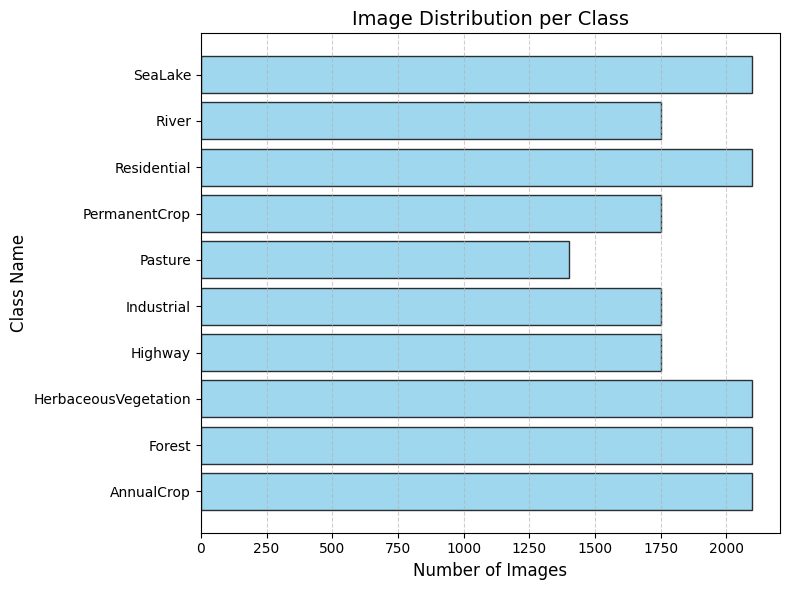

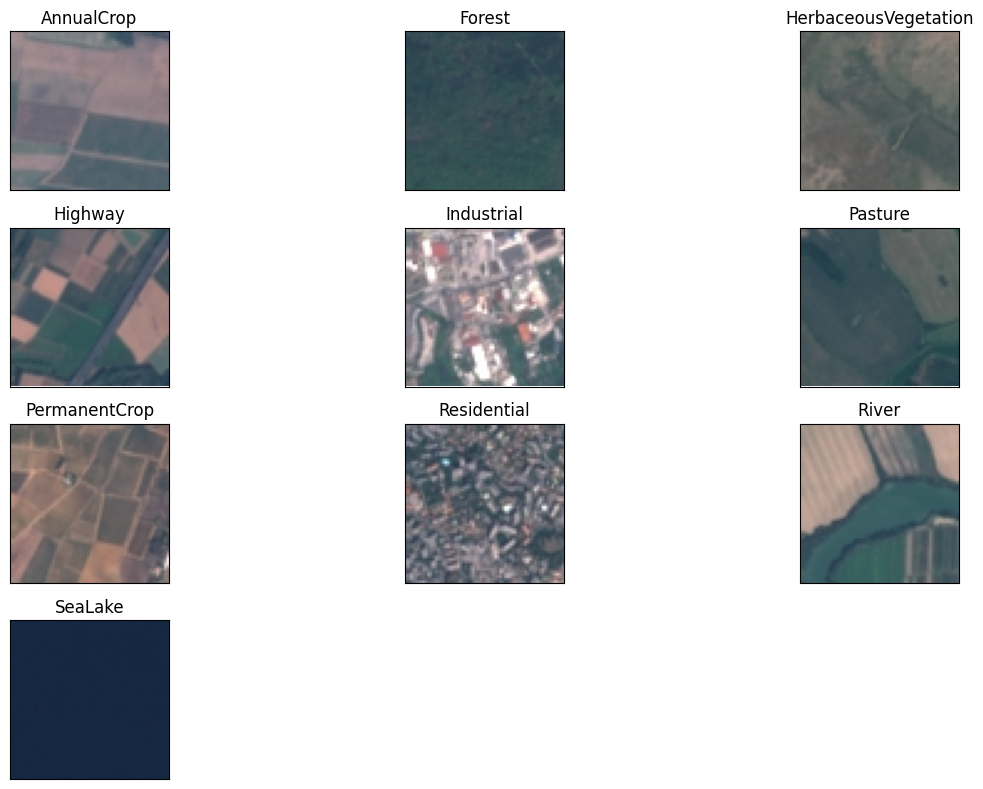

✅ Sample preview done.


In [ ]:
# ========= 统计与可视化（不依赖 load_image）（不改）
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# 统计每类数量
def statistic(train_dir=os.path.join(output_dir, 'train')):
    labels, counts = [], []
    for cname in sorted(os.listdir(train_dir)):
        cpath = os.path.join(train_dir, cname)
        if os.path.isdir(cpath):
            labels.append(cname)
            counts.append(len(os.listdir(cpath)))
    return labels, counts

labels, num_images = statistic()
print(f"📊 Total number of images in dataset: {sum(num_images)}")

# 类别分布柱状图
y_pos = np.arange(len(labels))
plt.figure(figsize=(8, 6))
plt.barh(y_pos, num_images, color='skyblue', edgecolor='black', alpha=0.8)
plt.yticks(y_pos, labels, fontsize=10)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Class Name', fontsize=12)
plt.title('Image Distribution per Class', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 简单示例图（每类取1张）
train_dir = os.path.join(output_dir, 'train')
samples, names = [], []
for cname in sorted(os.listdir(train_dir)):
    cpath = os.path.join(train_dir, cname)
    if os.path.isdir(cpath):
        files = os.listdir(cpath)
        if files:
            samples.append(Image.open(os.path.join(cpath, files[0])).convert('RGB'))
            names.append(cname)

n = min(len(samples), 12)
plt.figure(figsize=(12, 8))
for i in range(n):
    plt.subplot(4, 3, i+1)
    plt.imshow(samples[i])
    plt.title(names[i])
    plt.xticks([]); plt.yticks([])
plt.tight_layout(); plt.show()
print("✅ Sample preview done.")


In [ ]:
# ========= 类别名到ID的映射（最小正确写法） =========
def create_label_mapping(train_dir=os.path.join(output_dir, 'train')):
    classes = sorted([
        d for d in os.listdir(train_dir)
        if os.path.isdir(os.path.join(train_dir, d))
    ])
    return {cls: idx for idx, cls in enumerate(classes)}

label2id = create_label_mapping()
print("✅ label2id:", label2id)


✅ label2id: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


In [ ]:
# ====== Cell 1: Setup & utils ======
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
from tqdm import tqdm

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import normalize
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

# 设备与随机数
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)
print(f"🚀 Using device: {device}")

# 类别映射（与现有 ./dataset/train 对齐）
def create_label_mapping(train_dir=os.path.join(output_dir, 'train')):
    classes = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
    return {cls: idx for idx, cls in enumerate(classes)}


🚀 Using device: cuda


In [ ]:
# ====== Cell 2: Datasets & loaders ======
def collect_paths_labels(base_dir, label2id):
    """收集 base_dir 下所有图片路径和对应数字标签"""
    img_paths, labels = [], []
    for label, idx in label2id.items():
        class_dir = os.path.join(base_dir, label)
        if not os.path.isdir(class_dir):
            continue
        for fname in os.listdir(class_dir):
            p = os.path.join(class_dir, fname)
            if os.path.isfile(p) and p.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')):
                img_paths.append(p)
                labels.append(idx)
    return img_paths, labels

class ImageFolderPaths(Dataset):
    """从路径读取图片并做预处理"""
    def __init__(self, img_paths, labels, transform):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        path = self.img_paths[idx]
        img = Image.open(path).convert('RGB')
        img = self.transform(img)
        label = self.labels[idx]
        return img, label

# 预处理（ResNet 标准）
img_size = 224
transform = T.Compose([
    T.Resize((img_size, img_size)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

# 路径与映射
label2id = create_label_mapping()
id2label = {v: k for k, v in label2id.items()}
class_names = [id2label[i] for i in range(len(id2label))]
num_classes = len(class_names)
print(f"✅ Classes ({num_classes}): {class_names}")

# 收集路径
train_paths, train_labels = collect_paths_labels(os.path.join(output_dir, 'train'), label2id)
valid_paths, valid_labels = collect_paths_labels(os.path.join(output_dir, 'valid'), label2id)
test_paths,  test_labels  = collect_paths_labels(os.path.join(output_dir, 'test'),  label2id)

# DataLoader
batch_size = 64
train_loader = DataLoader(ImageFolderPaths(train_paths, train_labels, transform),
                          batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
valid_loader = DataLoader(ImageFolderPaths(valid_paths, valid_labels, transform),
                          batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(ImageFolderPaths(test_paths,  test_labels,  transform),
                          batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"🔢 Train/Valid/Test sizes: {len(train_paths)} / {len(valid_paths)} / {len(test_paths)}")


✅ Classes (10): ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
🔢 Train/Valid/Test sizes: 18899 / 4051 / 4050


In [ ]:
# ====== Cell 3: ResNet feature extractor ======
# 使用 ImageNet 预训练权重
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet.fc = nn.Identity()   # 去掉分类头，输出倒数第二层特征 (512 维)
resnet = resnet.to(device)
resnet.eval()
print("✅ ResNet18 loaded as feature extractor (fc -> Identity).")

@torch.no_grad()
def extract_features(dataloader, model, device):
    """从 DataLoader 提取 (N, D) 特征与 (N,) 标签"""
    feats, ys = [], []
    for imgs, labels in tqdm(dataloader, desc="Extracting features"):
        imgs = imgs.to(device, non_blocking=True)
        feat = model(imgs)                  # [B, 512]
        feats.append(feat.detach().cpu().numpy())
        ys.append(labels.numpy())
    feats = np.concatenate(feats, axis=0)
    ys = np.concatenate(ys, axis=0)
    return feats, ys


✅ ResNet18 loaded as feature extractor (fc -> Identity).


In [ ]:
# ====== Cell 4: Feature extraction & normalization ======
X_train_features, Y_train = extract_features(train_loader, resnet, device)
X_valid_features, Y_valid = extract_features(valid_loader, resnet, device)
X_test_features,  Y_test  = extract_features(test_loader,  resnet, device)

print(f"✅ Feature shapes -> train: {X_train_features.shape}, valid: {X_valid_features.shape}, test: {X_test_features.shape}")

# L2 归一化（KNN with Euclidean 更稳）
X_train_features = normalize(X_train_features, norm='l2')
X_valid_features = normalize(X_valid_features, norm='l2')
X_test_features  = normalize(X_test_features,  norm='l2')
print("✅ L2-normalized features.")


Extracting features: 100%|██████████| 64/64 [00:07<00:00,  8.10it/s]


✅ Feature shapes -> train: (18899, 512), valid: (4051, 512), test: (4050, 512)
✅ L2-normalized features.


🔍 Searching best K using validation set...
  K= 1 → Val Acc = 0.9055
  K= 2 → Val Acc = 0.9055
  K= 3 → Val Acc = 0.9178
  K= 4 → Val Acc = 0.9210
  K= 5 → Val Acc = 0.9203
  K= 6 → Val Acc = 0.9227
  K= 7 → Val Acc = 0.9222
  K= 8 → Val Acc = 0.9210
  K= 9 → Val Acc = 0.9227
  K=10 → Val Acc = 0.9185
  K=11 → Val Acc = 0.9185
  K=12 → Val Acc = 0.9178
  K=13 → Val Acc = 0.9171
  K=14 → Val Acc = 0.9180
  K=15 → Val Acc = 0.9161
  K=16 → Val Acc = 0.9166
  K=17 → Val Acc = 0.9173
  K=18 → Val Acc = 0.9158
  K=19 → Val Acc = 0.9161
  K=20 → Val Acc = 0.9156
  K=21 → Val Acc = 0.9151
  K=22 → Val Acc = 0.9143
  K=23 → Val Acc = 0.9126
  K=24 → Val Acc = 0.9134
  K=25 → Val Acc = 0.9109

✅ Best K on validation: K=6 with Acc=0.9227


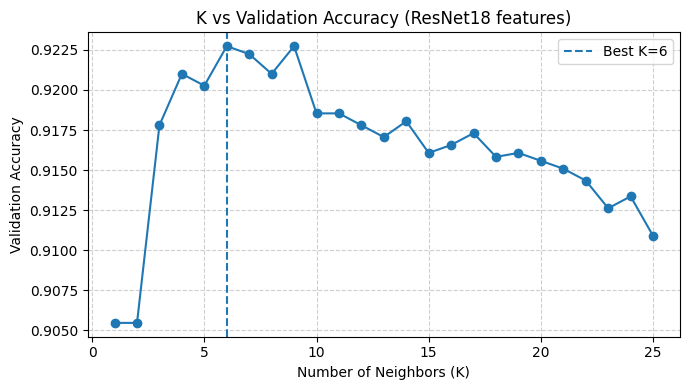

In [ ]:
# ====== Cell 5: Hyperparameter search on valid ======
k_values = list(range(1, 26))   # 可按需扩大
best_k, best_acc = None, 0.0
val_accuracies = []

print("🔍 Searching best K using validation set...")
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='distance')
    knn.fit(X_train_features, Y_train)
    pred_val = knn.predict(X_valid_features)
    acc = accuracy_score(Y_valid, pred_val)
    val_accuracies.append(acc)
    if acc > best_acc:
        best_acc, best_k = acc, k
    print(f"  K={k:2d} → Val Acc = {acc:.4f}")

print(f"\n✅ Best K on validation: K={best_k} with Acc={best_acc:.4f}")

# 可视化（验证集准确率随 K 变化）
plt.figure(figsize=(7, 4))
plt.plot(k_values, val_accuracies, marker='o')
plt.axvline(best_k, linestyle='--', label=f'Best K={best_k}')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Validation Accuracy')
plt.title('K vs Validation Accuracy (ResNet18 features)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


📊 Final Test Accuracy (best K=6): 0.9252

📋 Classification Report:
                      precision    recall  f1-score   support

          AnnualCrop     0.9324    0.9200    0.9262       450
              Forest     0.9332    0.9933    0.9623       450
HerbaceousVegetation     0.9365    0.9511    0.9438       450
             Highway     0.8657    0.8080    0.8359       375
          Industrial     0.9256    0.9627    0.9438       375
             Pasture     0.8774    0.9300    0.9029       300
       PermanentCrop     0.9256    0.8960    0.9106       375
         Residential     0.9236    0.9667    0.9446       450
               River     0.9112    0.8213    0.8640       375
             SeaLake     0.9909    0.9689    0.9798       450

            accuracy                         0.9252      4050
           macro avg     0.9222    0.9218    0.9214      4050
        weighted avg     0.9250    0.9252    0.9245      4050



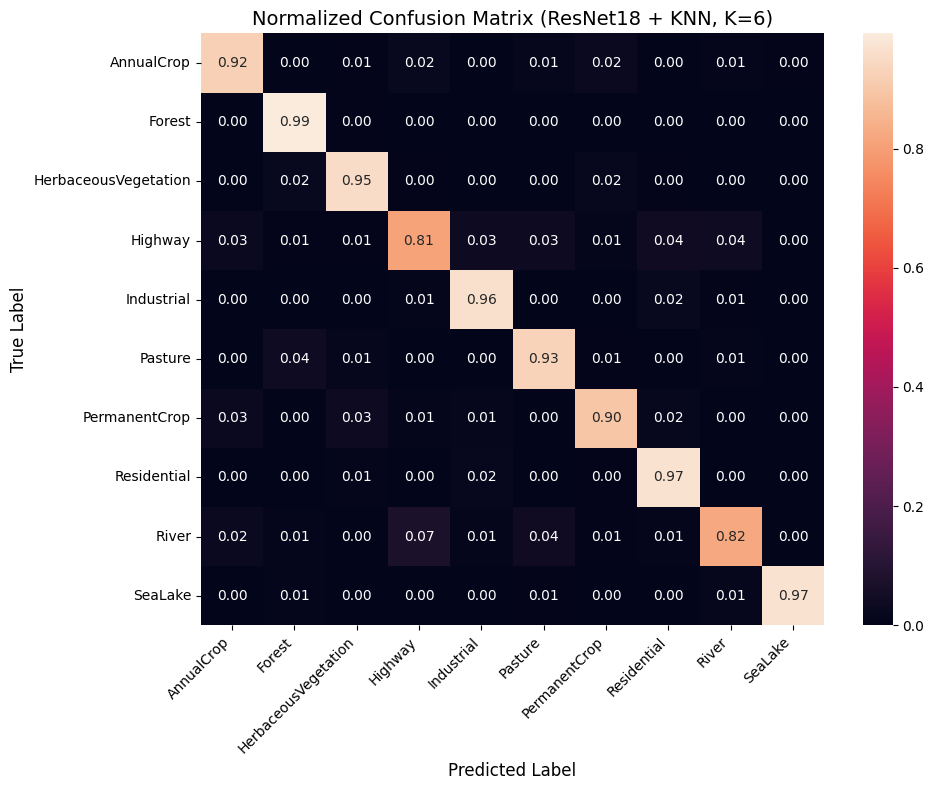

In [ ]:
# ====== Cell 6: Final eval on test set ======
knn_best = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', weights='distance')
knn_best.fit(X_train_features, Y_train)
Y_pred = knn_best.predict(X_test_features)

test_acc = accuracy_score(Y_test, Y_pred)
print(f"📊 Final Test Accuracy (best K={best_k}): {test_acc:.4f}")

print("\n📋 Classification Report:")
print(classification_report(Y_test, Y_pred, target_names=class_names, digits=4))

# 归一化混淆矩阵（行归一化）
cm = confusion_matrix(Y_test, Y_pred, labels=list(range(num_classes)))
cm_norm = cm.astype(np.float64) / (cm.sum(axis=1, keepdims=True) + 1e-12)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title(f'Normalized Confusion Matrix (ResNet18 + KNN, K={best_k})', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


原图大小: 2500 x 1131


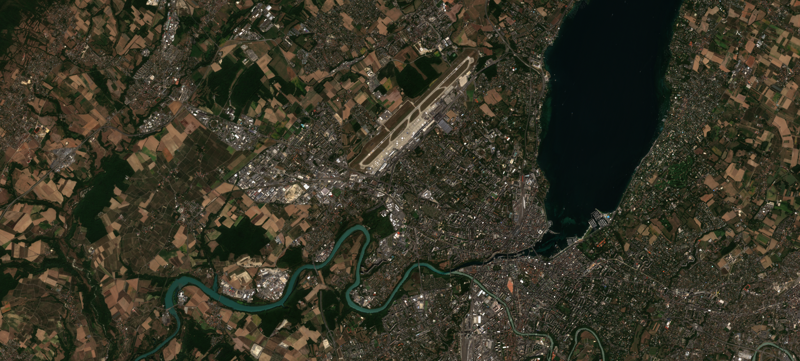

In [ ]:
# ====== Cell A: 读取一整张 Sentinel-2 原图 ======
from PIL import Image
import numpy as np

# 换成你自己的图片路径
raw_image_path = "/content/2025-08-18-00_00_2025-08-18-23_59_Sentinel-2_L2A_True_Color.png"   # TODO: 改成你的文件名

big_img = Image.open(raw_image_path).convert("RGB")
W, H = big_img.size
print(f"原图大小: {W} x {H}")  # 你这应该会打印 2500 x 1131

# 预览一下（缩小显示）
display(big_img.resize((min(W, 800), int(H * min(W, 800) / W))))



In [ ]:
# ====== Cell B: 把整图切成 64x64 小块 ======

patch_size = 64   # EuroSAT 的 patch 大小
stride = patch_size

# 只使用能整除的一部分区域
n_cols = W // patch_size          # 列数
n_rows = H // patch_size          # 行数

crop_w = n_cols * patch_size      # 实际用于分类的宽度
crop_h = n_rows * patch_size      # 实际用于分类的高度

print(f"用于网格的区域大小: {crop_w} x {crop_h}")
print(f"patch 网格: {n_rows} 行 x {n_cols} 列，共 {n_rows * n_cols} 个 patch")

# 先裁剪到可整除区域
big_img_cropped = big_img.crop((0, 0, crop_w, crop_h))

patches = []
patch_coords = []   # 记录每个 patch 在网格中的位置 (row, col)

for r in range(n_rows):
    for c in range(n_cols):
        left   = c * stride
        upper  = r * stride
        right  = left + patch_size
        lower  = upper + patch_size
        patch  = big_img_cropped.crop((left, upper, right, lower))
        patches.append(patch)
        patch_coords.append((r, c))

print("✅ patch 提取完成")


用于网格的区域大小: 2496 x 1088
patch 网格: 17 行 x 39 列，共 663 个 patch
✅ patch 提取完成


In [ ]:
# ====== Cell C: 对所有 patch 做预测（ResNet18 + KNN） ======
import torch
from sklearn.preprocessing import normalize

resnet.eval()
batch_size_eval = 128

all_preds = []

with torch.no_grad():
    for i in range(0, len(patches), batch_size_eval):
        batch_patches = patches[i : i + batch_size_eval]

        # 使用你前面定义好的 transform（Resize 到 224 + Normalize）
        batch_tensors = [transform(p) for p in batch_patches]
        batch = torch.stack(batch_tensors).to(device)

        # 提取 ResNet 特征
        feats = resnet(batch).cpu().numpy()

        # L2 归一化（与训练 KNN 时保持一致）
        feats_norm = normalize(feats, norm="l2")

        # 用最优 K 的 KNN 分类器预测
        preds = knn_best.predict(feats_norm)
        all_preds.extend(preds)

all_preds = np.array(all_preds)
print("✅ 预测完成，预测数量：", len(all_preds))

# reshape 成 (n_rows, n_cols) 网格
pred_grid = all_preds.reshape(n_rows, n_cols)
pred_grid.shape


✅ 预测完成，预测数量： 663


(17, 39)

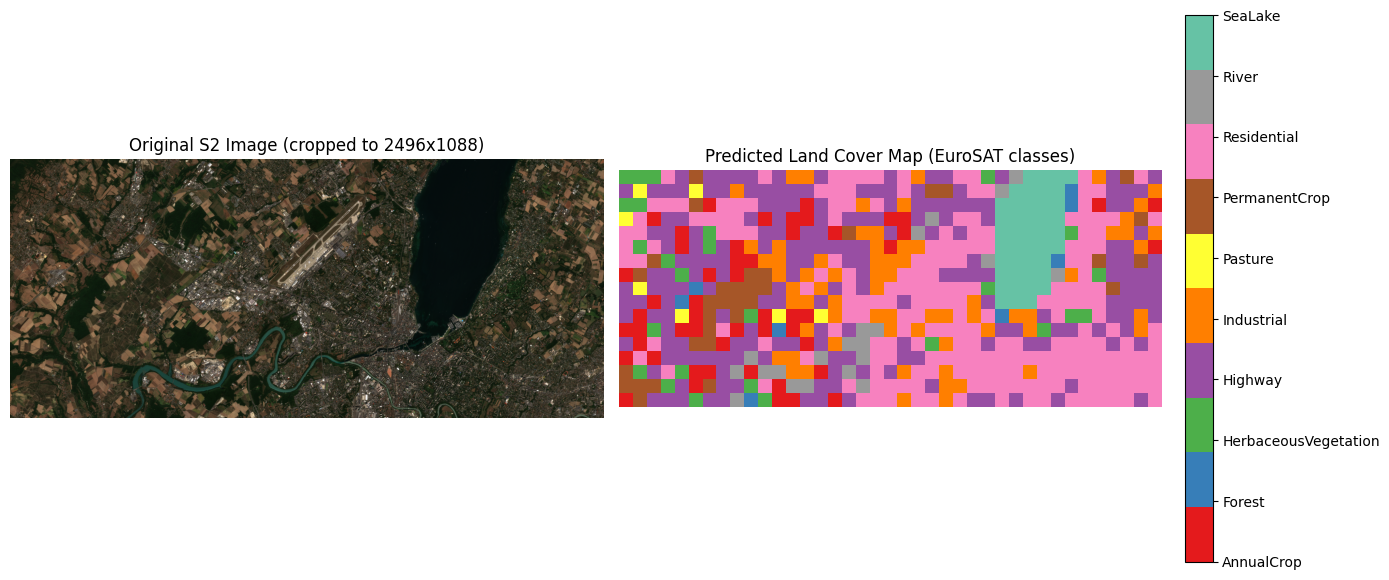

✅ Saved: full_image_prediction_colored.png
✅ Saved: comparison_original_vs_prediction.png


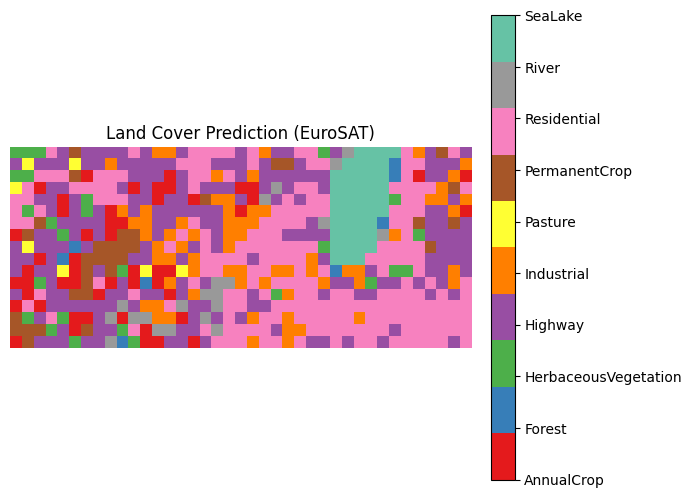

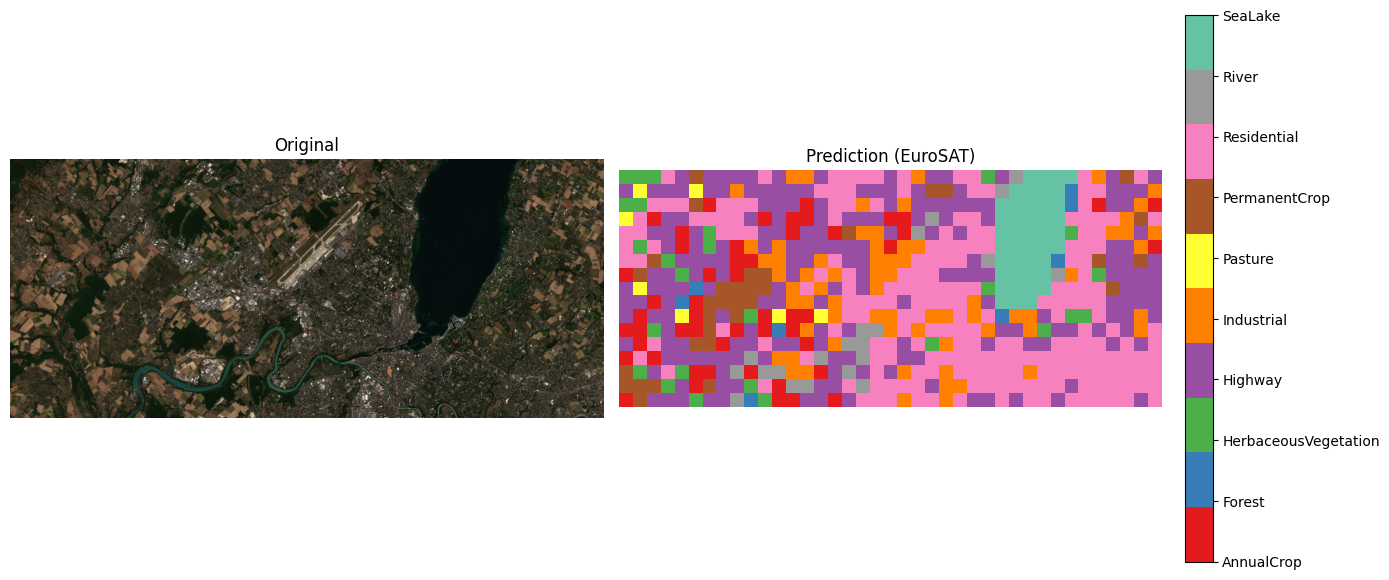

In [ ]:
# ====== Cell D (improved): 可视化整图分类结果（清晰分色版 + 保存图片） ======
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 为类别创建显眼的颜色（数量 >= 类别数即可）
color_list = [
    "#e41a1c", "#377eb8", "#4daf4a", "#984ea3", "#ff7f00",
    "#ffff33", "#a65628", "#f781bf", "#999999", "#66c2a5",
    "#fc8d62", "#8da0cb", "#e78ac3", "#a6d854", "#ffd92f",
    "#e5c494", "#b3b3b3"
]

# 确保颜色数量够（EuroSAT 13 类，这里给了 17）
assert len(color_list) >= len(class_names)

cmap = ListedColormap(color_list[:len(class_names)])

plt.figure(figsize=(14, 6))

# 左：裁剪后的原图
plt.subplot(1, 2, 1)
plt.imshow(big_img_cropped)
plt.title(f"Original S2 Image (cropped to {crop_w}x{crop_h})")
plt.axis("off")

# 右：分类结果图
plt.subplot(1, 2, 2)
im = plt.imshow(pred_grid, cmap=cmap, vmin=0, vmax=len(class_names)-1, interpolation="nearest")
plt.title("Predicted Land Cover Map (EuroSAT classes)")
plt.axis("off")

# 颜色条
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_ticks(range(len(class_names)))
cbar.set_ticklabels(class_names)

plt.tight_layout()
plt.show()

# ====== 保存图像 ======

# 1) 保存分类结果图（只有颜色图）
plt.figure(figsize=(7, 6))
im = plt.imshow(pred_grid, cmap=cmap, vmin=0, vmax=len(class_names)-1, interpolation="nearest")
plt.axis("off")
plt.title("Land Cover Prediction (EuroSAT)")
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_ticks(range(len(class_names)))
cbar.set_ticklabels(class_names)
plt.tight_layout()
plt.savefig("full_image_prediction_colored.png", dpi=300)
print("✅ Saved: full_image_prediction_colored.png")


# 2) 保存原图 vs 预测图的对比图
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.imshow(big_img_cropped)
plt.axis("off")
plt.title("Original")

plt.subplot(1, 2, 2)
im = plt.imshow(pred_grid, cmap=cmap, vmin=0, vmax=len(class_names)-1, interpolation="nearest")
plt.axis("off")
plt.title("Prediction (EuroSAT)")
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_ticks(range(len(class_names)))
cbar.set_ticklabels(class_names)

plt.tight_layout()
plt.savefig("comparison_original_vs_prediction.png", dpi=300)
print("✅ Saved: comparison_original_vs_prediction.png")
